##### load libraries

In [1]:
import os
import math
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import LeaveOneOut, StratifiedKFold
from sklearn.metrics import accuracy_score
from torch.utils.data import random_split
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

##### construct vae data

In [5]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

coh_base = '../data/COH/'
pli_base = '../data/PLI/'
ste_base = '../data/STE/'

BD_coh = load_pickle(os.path.join(coh_base, 'BD_coh_data.pkl'))
BD_pli = load_pickle(os.path.join(pli_base, 'BD_pli_data.pkl'))
MDD_coh = load_pickle(os.path.join(coh_base, 'MDD_coh_data.pkl'))
MDD_pli = load_pickle(os.path.join(pli_base, 'MDD_pli_data.pkl'))
BD_ste = load_pickle(os.path.join(ste_base, 'BD_ste_data.pkl'))
MDD_ste = load_pickle(os.path.join(ste_base, 'MDD_ste_data.pkl'))

frequency_bands = ['delta', 'theta', 'alpha', 'betalow', 'betahigh', 'gamma']

In [6]:
def vector_to_mat(vector, n=29):
    mat = np.zeros((n, n), dtype=vector.dtype)
    triu = np.triu_indices(n, k=1)
    mat[triu] = vector
    mat[(triu[1], triu[0])] = vector
    np.fill_diagonal(mat, 1)
    return mat


def build_subject_tensor(subj, coh_dict, pli_dict, ste_dict):
    mats = []
    for band in frequency_bands:
        mats.append(vector_to_mat(coh_dict[subj][band]))
    for band in frequency_bands:
        mats.append(vector_to_mat(pli_dict[subj][band]))
    for band in frequency_bands:
        m = ste_dict[subj][band].copy()
        np.fill_diagonal(m, 1)
        mats.append(m)
    # shape: (18, 29, 29)
    return np.stack(mats, axis=0)

In [7]:
BD_subjs = sorted(BD_coh.keys())
MDD_subjs = sorted(MDD_coh.keys())

n_train_BD = 45
n_train_MDD = 45

train_bd = BD_subjs[:n_train_BD]
test_bd  = BD_subjs[n_train_BD:]
train_mdd = MDD_subjs[:n_train_MDD]
test_mdd  = MDD_subjs[n_train_MDD:]


vae_train_subjs = train_bd + train_mdd
vae_labels = [0]*len(train_bd) + [1]*len(train_mdd)

X_data = np.stack([
    build_subject_tensor(s, BD_coh, BD_pli, BD_ste) if i < len(train_bd)
    else build_subject_tensor(s, MDD_coh, MDD_pli, MDD_ste)
    for i, s in enumerate(vae_train_subjs)
], axis=0)
Y_data = np.eye(2)[vae_labels]

X_t = torch.tensor(X_data, dtype=torch.float32)
C_t = torch.tensor(Y_data, dtype=torch.float32)
vae_dataset = TensorDataset(X_t, C_t)
train_loader = DataLoader(vae_dataset, batch_size=16, shuffle=True)

##### vae model & functions

In [8]:
class cVAE2d(nn.Module):
    def __init__(self, in_ch=18, latent_dim=50, num_classes=2, H=29, W=29):
        super().__init__()
        self.in_ch = in_ch
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.ds_h = math.ceil(H / 8)
        self.ds_w = math.ceil(W / 8)
        # Encoder
        self.enc_conv = nn.Sequential(
            nn.Conv2d(in_ch, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.fc_enc = nn.Sequential(
            nn.Linear(256 * self.ds_h * self.ds_w + num_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256 * self.ds_h * self.ds_w),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.dec_deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, in_ch, kernel_size=3, stride=2, padding=1, output_padding=1)
        )

    def encode(self, x, c):
        h = self.enc_conv(x)                                # (B,256,ds_h,ds_w)
        h = h.view(h.size(0), -1)                           # (B,256*ds_h*ds_w)
        h = torch.cat([h, c], dim=1)                        # (B,*,+num_classes)
        h = self.fc_enc(h)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        zc = torch.cat([z, c], dim=1)
        h = self.fc_dec(zc)                                 # (B,256*ds_h*ds_w)
        h = h.view(-1, 256, self.ds_h, self.ds_w)           # (B,256,ds_h,ds_w)
        x_recon = self.dec_deconv(h)                        # (B,in_ch,>=H,>=W)
        return x_recon[:, :, :29, :29]

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

In [9]:
def loss_fn(recon,x,mu,logvar,beta=1.0):
    rec = F.mse_loss(recon,x,reduction='mean')*x.numel()/x.size(0)
    kl = -0.5*torch.mean(1+logvar-mu.pow(2)-logvar.exp())
    return rec + beta * kl, rec.item(), kl.item()

In [10]:
def train_vae(model, loader, epochs=100, lr=1e-3, beta=1.0, early_stop=False, patience=20):

    opt = optim.Adam(model.parameters(),lr=lr)
    best, no_imp = float('inf'),0
    hist = {'rec':[], 'kl':[]}

    for e in tqdm(range(1, epochs+1), desc='Training Epochs'):  # Epoch-level TQDM
        model.train()
        rec_sum = kl_sum = count = 0

        curr_beta = beta * (e / epochs)

        for x, c in loader:
            x, c = x.to(device), c.to(device)
            opt.zero_grad()
            recon, mu, logvar = model(x, c)
            loss, r, k = loss_fn(recon, x, mu, logvar, curr_beta)
            loss.backward()
            opt.step()
            b = x.size(0)
            rec_sum += r * b
            kl_sum += k * b
            count += b

        hist['rec'].append(rec_sum / count)
        hist['kl'].append(kl_sum / count)

        if early_stop:
            total_loss = hist['rec'][-1] + beta * hist['kl'][-1]
            if total_loss < best:
                best, no_imp = total_loss, 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    print(f"Early stopping at epoch {e}")
                    break

    return model, hist

In [9]:
latent_dim = 100
beta = 1.0
epochs = 500
lr = 1e-3
vae = cVAE2d().to(device)
vae, history = train_vae(vae, train_loader, epochs, lr, beta, early_stop=True, patience=20)

KeyboardInterrupt: 

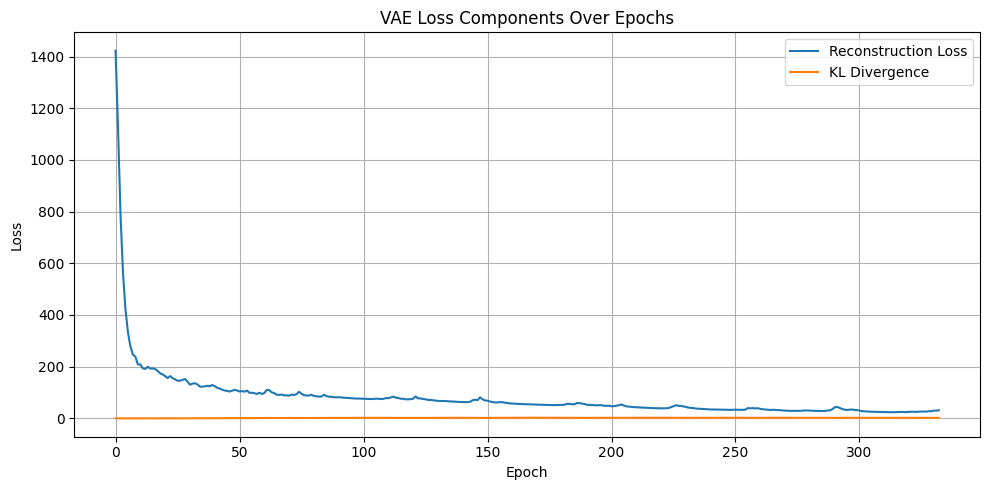

In [35]:
sns.reset_defaults()

plt.figure(figsize=(10, 5))
plt.plot(history['rec'], label='Reconstruction Loss')
plt.plot(history['kl'], label='KL Divergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Loss Components Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### cnn model & functions

In [11]:
class EEG_CNN(nn.Module):
    def __init__(self, in_ch=18, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(512)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(512, 256)
        self.fc2   = nn.Linear(256, 128)
        self.fc3   = nn.Linear(128, 64)
        self.fc4   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

In [12]:
def train_cnn(model, train_loader, val_loader=None, epochs=500, patience=50, lr=1e-5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    no_improve = 0
    best_state = None

    for epoch in tqdm(range(1, epochs+1), desc='CNN Epochs'):
        # Training
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)

        # Validation
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    out = model(xb)
                    loss = criterion(out, yb)
                    val_loss += loss.item() * xb.size(0)
            val_loss /= len(val_loader.dataset)
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                no_improve = 0
                best_state = model.state_dict()
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"Early stopping CNN at epoch {epoch}")
                    break

    # Load best weights if available
    if best_state is not None:
        model.load_state_dict(best_state)

In [13]:
all_train = [(build_subject_tensor(s, BD_coh, BD_pli, BD_ste), 0) for s in train_bd] + \
            [(build_subject_tensor(s, MDD_coh, MDD_pli, MDD_ste), 1) for s in train_mdd]
all_test  = [(build_subject_tensor(s, BD_coh, BD_pli, BD_ste), 0) for s in test_bd] + \
            [(build_subject_tensor(s, MDD_coh, MDD_pli, MDD_ste), 1) for s in test_mdd]


X_train_np = np.stack([x for x, _ in all_train], axis=0)
y_train_np = np.array([y for _, y in all_train])
X_test_np  = np.stack([x for x, _ in all_test], axis=0)
y_test_np  = np.array([y for _, y in all_test])

# testing set tensors
X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_np, dtype=torch.long).to(device)

In [14]:
def generate_samples(model, n_samples, cond):

    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.latent_dim, device=device)
        cond = cond.to(device)
        synth = model.decode(z, cond)
        return synth.cpu().numpy()
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent_dim, device=device)
        cond = cond.to(device)
        synth = model.decode(z, cond)
        return synth.cpu().numpy()

In [15]:
epochs = 500
batch_size = 16

use_early_stopping = True
patience = 50   
 
use_loocv = True       
draw_loocv_cm = True 

##### data generation (previous)

In [61]:
gen_counts = list(range(10, 251, 10))
rs = gen_counts
all_generated = {}
cv_scores = []
test_scores = []


for r in rs:
    best_test_acc = -np.inf
    best_synth0 = None
    best_synth1 = None
    best_cv_acc = None

    for trial in range(3):
        
        cond0 = torch.zeros(r, vae.num_classes, device=device) 
        cond0[:, 0] = 1
        cond1 = torch.zeros(r, vae.num_classes, device=device)
        cond1[:, 1] = 1

        synth0_c = generate_samples(vae, r, cond0)
        synth1_c = generate_samples(vae, r, cond1)

       
        X_aug = np.concatenate([X_train_np, synth0_c, synth1_c], axis=0)
        y_aug = np.concatenate([y_train_np, np.zeros(r), np.ones(r)], axis=0)

        # 10-fold CV on augmented dataset
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        fold_accs = []
        for tr_idx, te_idx in skf.split(X_aug, y_aug):
            # fold  DataLoader
            X_tr, y_tr = X_aug[tr_idx], y_aug[tr_idx]
            X_te, y_te = X_aug[te_idx], y_aug[te_idx]
            ds_tr = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )
            ds_te = TensorDataset(
                torch.tensor(X_te, dtype=torch.float32),
                torch.tensor(y_te, dtype=torch.long)
            )
            loader_tr = DataLoader(ds_tr, batch_size=16, shuffle=True)
            loader_te = DataLoader(ds_te, batch_size=16, shuffle=False)

            # train on this fold
            cnn_cv = EEG_CNN().to(device)
            train_cnn(cnn_cv, loader_tr, loader_te, epochs=500, patience=50)

            # predict on this fold
            cnn_cv.eval()
            y_true_cv, y_pred_cv = [], []
            with torch.no_grad():
                for x_batch, y_batch in loader_te:
                    x_batch = x_batch.to(device)
                    # train_cnn internal handles correct permute if needed
                    preds = torch.argmax(cnn_cv(x_batch), dim=1)
                    y_pred_cv.extend(preds.cpu().numpy())
                    y_true_cv.extend(y_batch.numpy())
            fold_accs.append(accuracy_score(y_true_cv, y_pred_cv))

        cv_acc_mean = np.mean(fold_accs)



        # Inde. test
        cnn = EEG_CNN().to(device)
        ds_aug = TensorDataset(
            torch.tensor(X_aug, dtype=torch.float32),
            torch.tensor(y_aug, dtype=torch.long)
        )
        n_tr = int(0.85 * len(ds_aug))
        n_val = len(ds_aug) - n_tr
        tr_ds, val_ds = random_split(ds_aug, [n_tr, n_val])
        tr_loader = DataLoader(tr_ds, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
        train_cnn(cnn, tr_loader, val_loader, epochs=500, patience=50)

        cnn.eval()
        with torch.no_grad():
            preds_test = torch.argmax(cnn(X_test_t), dim=1).cpu().numpy()
        test_acc = accuracy_score(y_test_np, preds_test)

        # find the best results
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_synth0 = synth0_c
            best_synth1 = synth1_c
            best_cv_acc = cv_acc_mean

    all_generated[r] = {'synth0': best_synth0, 'synth1': best_synth1}
    cv_scores.append(best_cv_acc)
    test_scores.append(best_test_acc)
    print(f"r={r:3d} | 10-fold CV Acc: {best_cv_acc:.4f} | Independent Test Acc: {best_test_acc:.4f}")

CNN Epochs:  19%|█▉        | 95/500 [00:03<00:14, 27.54it/s]


Early stopping CNN at epoch 96


CNN Epochs:  59%|█████▊    | 293/500 [00:09<00:06, 30.67it/s]


Early stopping CNN at epoch 294


CNN Epochs:  26%|██▌       | 129/500 [00:04<00:12, 29.14it/s]


...

Early stopping CNN at epoch 165


CNN Epochs:  24%|██▍       | 122/500 [00:18<00:56,  6.63it/s]


Early stopping CNN at epoch 123


CNN Epochs:  23%|██▎       | 117/500 [00:17<00:57,  6.61it/s]

Early stopping CNN at epoch 118
r=250 | 10-fold CV Acc: 0.9102 | Independent Test Acc: 0.7436


##### data generation

In [20]:
gen_counts = list(range(10, 251, 10))
rs = gen_counts
all_generated = {}
cv_scores = []
test_scores = []

for r in rs:
    best_test_acc = -float("inf")
    best_record = {}


    for trial in range(2):
 
        cond0 = torch.zeros(r, vae.num_classes, device=device)
        cond0[:, 0] = 1
        cond1 = torch.zeros(r, vae.num_classes, device=device)
        cond1[:, 1] = 1

    
        synth0 = generate_samples(vae, r, cond0)
        synth1 = generate_samples(vae, r, cond1)


        X_aug = np.concatenate([X_train_np, synth0, synth1], axis=0)
        y_aug = np.concatenate([y_train_np, np.zeros(r), np.ones(r)], axis=0)

     
        cnn = EEG_CNN().to(device)
        ds_aug = TensorDataset(
            torch.tensor(X_aug, dtype=torch.float32),
            torch.tensor(y_aug, dtype=torch.long)
        )
        n_tr = int(0.85 * len(ds_aug))
        n_val = len(ds_aug) - n_tr
        tr_ds, val_ds = random_split(ds_aug, [n_tr, n_val])
        tr_loader = DataLoader(tr_ds, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

        train_cnn(cnn, tr_loader, val_loader, epochs=500, patience=50)

        cnn.eval()
        with torch.no_grad():
            preds_test = torch.argmax(cnn(X_test_t), dim=1).cpu().numpy()
        test_acc = accuracy_score(y_test_np, preds_test)

     
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_record = {
                'synth0': synth0,
                'synth1': synth1,
                'cnn_indep_state': cnn.state_dict(),   
                'test_preds': preds_test,
                'test_true': y_test_np.copy(),
                'X_test': X_test_t.cpu().numpy().copy(),
                'X_aug': X_aug.copy(),
                'y_aug': y_aug.copy()
            }

   
    X_aug = best_record['X_aug']
    y_aug = best_record['y_aug']
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_preds = []
    cv_true = []

    for tr_idx, te_idx in skf.split(X_aug, y_aug):
        
        X_tr, y_tr = X_aug[tr_idx], y_aug[tr_idx]
        X_te, y_te = X_aug[te_idx], y_aug[te_idx]
        ds_tr = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )
        ds_te = TensorDataset(
            torch.tensor(X_te, dtype=torch.float32),
            torch.tensor(y_te, dtype=torch.long)
        )
        loader_tr = DataLoader(ds_tr, batch_size=16, shuffle=True)
        loader_te = DataLoader(ds_te, batch_size=16, shuffle=False)

        cnn_cv = EEG_CNN().to(device)
        train_cnn(cnn_cv, loader_tr, loader_te, epochs=500, patience=50)


        cnn_cv.eval()
        with torch.no_grad():
            for x_batch, _ in loader_te:
                preds = torch.argmax(cnn_cv(x_batch.to(device)), dim=1)
                cv_preds.extend(preds.cpu().numpy())
        cv_true.extend(y_te)


    cv_acc_mean = accuracy_score(cv_true, cv_preds)


    best_record.update({
        'cv_preds': np.array(cv_preds),
        'cv_true': np.array(cv_true)
    })


    all_generated[r] = best_record
    test_scores.append(best_test_acc)
    cv_scores.append(cv_acc_mean)

    print(f"r={r:3d} | Best Independent Test Acc: {best_test_acc:.4f} | 5-fold CV Acc: {cv_acc_mean:.4f}")


CNN Epochs:  20%|██        | 101/500 [00:04<00:16, 24.57it/s]


Early stopping CNN at epoch 102


CNN Epochs:  33%|███▎      | 164/500 [00:06<00:13, 25.28it/s]


Early stopping CNN at epoch 165


CNN Epochs:  21%|██▏       | 107/500 [00:04<00:15, 25.18it/s]


...

Early stopping CNN at epoch 114


CNN Epochs:  16%|█▌        | 79/500 [00:15<01:20,  5.26it/s]


Early stopping CNN at epoch 80


CNN Epochs:  14%|█▍        | 72/500 [00:13<01:19,  5.35it/s]

Early stopping CNN at epoch 73
r=250 | Best Independent Test Acc: 0.7436 | 5-fold CV Acc: 0.9729


##### FID calculation

In [54]:
import torch
import numpy as np
import random
from scipy import linalg
from torchvision.models import inception_v3, Inception_V3_Weights
from torch import nn
import torch.nn.functional as F

# 1. 設備與隨機種子
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# 2. 載入預訓練 InceptionV3（ImageNet 權重）
weights = Inception_V3_Weights.IMAGENET1K_V1
inception = inception_v3(weights=weights, transform_input=False).to(device)

# 將 AuxLogits 設為 None，關閉 auxiliary head
inception.AuxLogits = None
inception.aux_logits = False

# 3. 修改第一層 conv 由 3→18 channels
orig_conv = inception.Conv2d_1a_3x3.conv
new_conv = nn.Conv2d(
    in_channels=18,
    out_channels=orig_conv.out_channels,
    kernel_size=orig_conv.kernel_size,
    stride=orig_conv.stride,
    padding=orig_conv.padding,
    bias=False
).to(device)

with torch.no_grad():
    w = orig_conv.weight             # shape=(out_c,3,k,k)
    w_mean = w.mean(dim=1, keepdim=True)  # shape=(out_c,1,k,k)
    new_conv.weight[:] = w_mean.repeat(1, 18, 1, 1)

inception.Conv2d_1a_3x3.conv = new_conv

# 移除最後分類頭，只保留 2048 維特徵
inception.fc = nn.Identity()
inception.eval()


# 4. 定義特徵擷取與 FID 計算
def get_embeddings(x: np.ndarray, batch_size: int = 16, target_size=(299,299)) -> np.ndarray:
    embeds = []
    N = x.shape[0]
    with torch.no_grad():
        for i in range(0, N, batch_size):
            batch = torch.from_numpy(x[i:i+batch_size]).float().to(device)  # (b,18,29,29)
            batch = F.interpolate(batch, size=target_size, mode='bilinear', align_corners=False)
            feat = inception(batch)           # (b,2048)
            embeds.append(feat.cpu().numpy())
    return np.vstack(embeds)

def calculate_fid(real: np.ndarray, fake: np.ndarray, batch_size: int = 16) -> float:
    act1 = get_embeddings(real, batch_size)
    act2 = get_embeddings(fake, batch_size)
    mu1, mu2 = act1.mean(axis=0), act2.mean(axis=0)
    sigma1 = np.cov(act1, rowvar=False)
    sigma2 = np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))


# -----------------------------------------------------------------------------
# 假設已經有：
#   X_train_np, y_train_np: 原始資料 shape=(N,18,29,29)
#   all_generated: dict{r: {'synth0':…, 'synth1':…}, …}
# -----------------------------------------------------------------------------

# 5. Augmented vs Real 的 FID
fid_vals = []
for r, rec in all_generated.items():
    synth0, synth1 = rec['synth0'], rec['synth1']
    real0 = X_train_np[y_train_np == 0]
    real1 = X_train_np[y_train_np == 1]

    # 如果 r > 可用樣本數就開放放回抽樣
    replace0 = r > len(real0)
    replace1 = r > len(real1)
    idx0 = np.random.choice(len(real0), r, replace=replace0)
    idx1 = np.random.choice(len(real1), r, replace=replace1)

    fid0 = calculate_fid(real0[idx0], synth0)
    fid1 = calculate_fid(real1[idx1], synth1)
    fid_vals.append((fid0 + fid1) / 2)

mean_fid_aug = np.mean(fid_vals)
print(f"Augmented vs Real 平均 FID over all r: {mean_fid_aug:.4f}")

# 6. Real vs Real (50/50 split)
fid_real = []
for cls in [0, 1]:
    samples = X_train_np[y_train_np == cls]
    perm = np.random.permutation(len(samples))
    half = len(perm) // 2
    real_a = samples[perm[:half]]
    real_b = samples[perm[half:half*2]]
    fid_real.append(calculate_fid(real_a, real_b))

mean_fid_real = np.mean(fid_real)
print(f"Real vs Real (50/50 split) FID: {mean_fid_real:.4f}")

# 7. Gaussian Noise vs Real
fid_noise = []
for cls in [0, 1]:
    real = X_train_np[y_train_np == cls]
    mu, sigma = real.mean(), real.std()
    noise = np.random.normal(mu, sigma, size=real.shape).astype(np.float32)
    fid_noise.append(calculate_fid(real, noise))

mean_fid_noise = np.mean(fid_noise)
print(f"Gaussian Noise vs Real FID: {mean_fid_noise:.4f}")


Augmented vs Real 平均 FID over all r: 96.2348
Real vs Real (50/50 split) FID: 57.0339
Gaussian Noise vs Real FID: 303.7759


##### SWD calculation

In [19]:
def calculate_swd(real: np.ndarray,
                  fake: np.ndarray,
                  n_projections: int = 100,
                  random_state: int = 42) -> float:

    rng = np.random.RandomState(random_state)
    # flatten each sample
    real_flat = real.reshape(real.shape[0], -1)   # (N, D)
    fake_flat = fake.reshape(fake.shape[0], -1)   # (M, D)
    D = real_flat.shape[1]
    
    swds = []
    for _ in range(n_projections):

        direction = rng.normal(size=(D,))
        direction /= np.linalg.norm(direction)

        proj_real = real_flat.dot(direction)
        proj_fake = fake_flat.dot(direction)

        proj_real.sort()
        proj_fake.sort()

        L = max(len(proj_real), len(proj_fake))
        if len(proj_real) < L:
            proj_real = np.interp(np.linspace(0,1,L), np.linspace(0,1,len(proj_real)), proj_real)
        if len(proj_fake) < L:
            proj_fake = np.interp(np.linspace(0,1,L), np.linspace(0,1,len(proj_fake)), proj_fake)
        swds.append(np.mean(np.abs(proj_real - proj_fake)))
    return float(np.mean(swds))



# 1. Augmented vs Real  SWD
swd_vals = []
for r, rec in all_generated.items():
    synth0, synth1 = rec['synth0'], rec['synth1']
    real0 = X_train_np[y_train_np == 0]
    real1 = X_train_np[y_train_np == 1]
    
    replace0 = r > len(real0)
    replace1 = r > len(real1)
    
    idx0 = np.random.choice(len(real0),  r, replace=replace0)
    idx1 = np.random.choice(len(real1),  r, replace=replace1)
    real0_samp = real0[idx0]
    real1_samp = real1[idx1]
    
    swd0 = calculate_swd(real0_samp, synth0)
    swd1 = calculate_swd(real1_samp, synth1)
    swd_vals.append((swd0 + swd1) / 2)

mean_swd_aug = np.mean(swd_vals)
print(f"Augmented vs Real 平均 SWD over all r: {mean_swd_aug:.6f}")



# 2. Real vs Real (50/50 split)  SWD
swd_real = []
for cls in [0, 1]:
    samples = X_train_np[y_train_np == cls]
    perm = np.random.permutation(len(samples))
    half = len(perm) // 2
    real_a = samples[perm[:half]]
    real_b = samples[perm[half:half*2]]
    swd_real.append(calculate_swd(real_a, real_b))

mean_swd_real = np.mean(swd_real)
print(f"Real vs Real (50/50 split) 平均 SWD: {mean_swd_real:.6f}")


# 3. Gaussian Noise vs Real  SWD
swd_noise = []
for cls in [0, 1]:
    real = X_train_np[y_train_np == cls]
    mu, sigma = real.mean(), real.std()
    noise = np.random.normal(mu, sigma, size=real.shape).astype(np.float32)
    swd_noise.append(calculate_swd(real, noise))

mean_swd_noise = np.mean(swd_noise)
print(f"Gaussian Noise vs Real 平均 SWD: {mean_swd_noise:.6f}")


Augmented vs Real 平均 SWD over all r: 0.054451
Real vs Real (50/50 split) 平均 SWD: 0.033067
Gaussian Noise vs Real 平均 SWD: 0.216357


##### plot

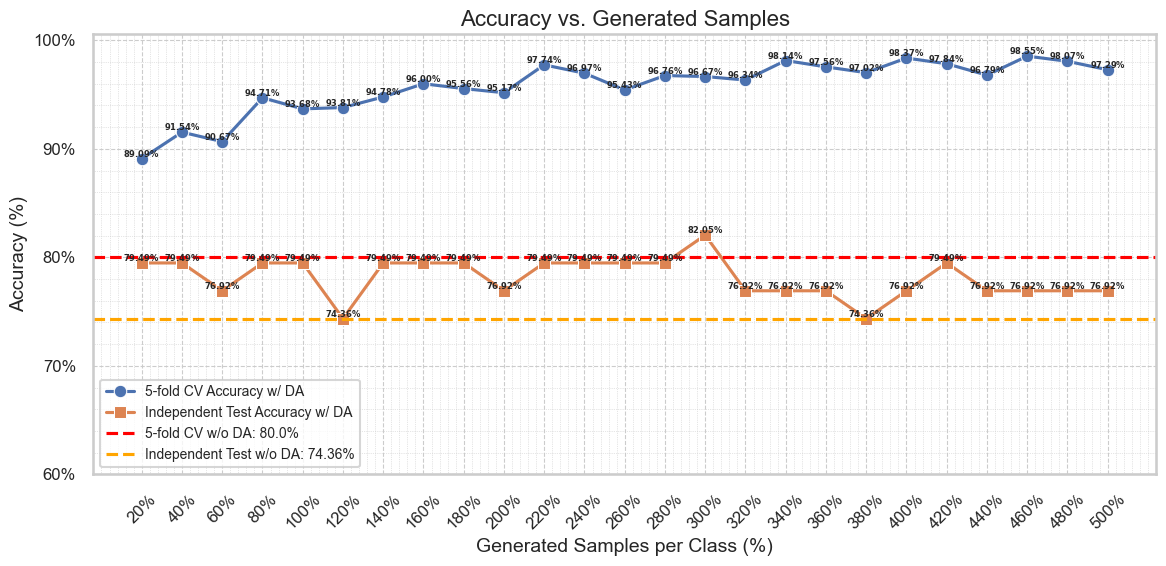

In [17]:
gen_counts = list(range(10, 251, 10))
rs = gen_counts

cv_pct   = [s * 100 for s in cv_scores]
test_pct = [s * 100 for s in test_scores]
min_val = min(cv_pct + test_pct)
lower = max(int(np.floor((min_val - 10) / 10)) * 10, 0)
max_val = max(cv_pct + test_pct)
upper = min(max_val + 2, 102)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(12, 6))



sns.lineplot(x=rs, y=cv_pct, marker="o",
             label="5-fold CV Accuracy w/ DA", ax=ax, clip_on=False)
sns.lineplot(x=rs, y=test_pct, marker="s",
             label="Independent Test Accuracy w/ DA", ax=ax, clip_on=False)



for x, y in zip(rs, cv_pct):
    ax.text(x, y, f"$\\mathbf{{{y:.2f}\\%}}$", va='bottom', ha='center', fontsize=6, clip_on=False)
for x, y in zip(rs, test_pct):
    ax.text(x, y, f"$\\mathbf{{{y:.2f}\\%}}$", va='bottom', ha='center', fontsize=6, clip_on=False)



baseline1 = 80.00
baseline2 = 74.36
ax.axhline(baseline1, linestyle='--', color='red',
           label=f"5-fold CV w/o DA: {baseline1}%", clip_on=False)
ax.axhline(baseline2, linestyle='--', color='orange',
           label=f"Independent Test w/o DA: {baseline2}%", clip_on=False)



ax.set_xticks(rs)
ax.tick_params(axis='both', labelsize=12)   
ax.set_xticklabels([f"{x*2}%" for x in rs], rotation=45)
ax.set_ylim(lower, upper)
yticks = list(range(lower, 101, 10))
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y}%" for y in yticks])

ax.set_xlabel("Generated Samples per Class (%)", fontsize=14)
ax.set_ylabel("Accuracy (%)", fontsize=14)
ax.set_title("Accuracy vs. Generated Samples", fontsize=16)
ax.minorticks_on()
ax.grid(which="major", linestyle="--", linewidth=0.8)
ax.grid(which="minor", linestyle=":", linewidth=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
# plt.savefig("../result_DL/BD_MDD/w_DA/vae/accuracy_vs_generated_samples.png", dpi=300)
plt.show()

##### average accuracy

In [18]:
# ave accuracy after DA
ave_cv_acc = np.mean(cv_scores)
ave_test_acc = np.mean(test_scores)
print(f"Average 5-fold CV Accuracy with DA: {ave_cv_acc:.4f}")
print(f"Average Independent Test Accuracy with DA: {ave_test_acc:.4f}")

Average 5-fold CV Accuracy with DA: 0.9578
Average Independent Test Accuracy with DA: 0.7815


##### save generated data & model

In [23]:
### save all generated data
with open('../result_DL/BD_MDD/w_DA/vae/all_generated_samples.pkl', 'wb') as f:
    pickle.dump(all_generated, f)

### save all history
with open('../result_DL/BD_MDD/w_DA/vae/cv_test_scores.pkl', 'wb') as f:
    pickle.dump({'cv_scores': cv_scores, 'test_scores': test_scores}, f)


In [24]:
### save model
vae_best_model = vae.state_dict()
with open("../result_DL/BD_MDD/w_DA/vae/model/vae_model.pt", "wb") as f:
    torch.save(vae_best_model, f)

##### load previous result

In [16]:
with open('../result_DL/BD_MDD/w_DA/bvae/all_generated_samples.pkl', 'rb') as f:
    all_generated = pickle.load(f)


with open('../result_DL/BD_MDD/w_DA/bvae/cv_test_scores.pkl', 'rb') as f:
    history = pickle.load(f)
    cv_scores   = history['cv_scores']
    test_scores = history['test_scores']


state_dict = torch.load('../result_DL/BD_MDD/w_DA/bvae/model/vae_model.pt', map_location='cpu')
vae = cVAE2d().to(device)
vae.load_state_dict(state_dict)
vae.eval()  

C:\Users\NESS-Kuan\AppData\Local\Temp\ipykernel_41160\4238357620.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('../result_DL/BD_MDD/w_DA/bvae/

cVAE2d(
  (enc_conv): Sequential(
    (0): Conv2d(18, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc_enc): Sequential(
    (0): Linear(in_features=4098, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (fc_mu): Linear(in_features=256, out_features=50, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=50, bias=True)
  (fc_dec): Sequential(
    (0): Linear(in_features=52, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=51

##### plot t-sne & confusion matrix

In [20]:
sns.reset_defaults()
best_r_test = rs[int(np.argmax(test_scores))]
best_r_cv   = rs[int(np.argmax(cv_scores))]

In [21]:
def plot_combined_confusion_cnn(r, record, path=None):
    cm_cv   = confusion_matrix(record['cv_true'],   record['cv_preds'])
    cm_test = confusion_matrix(record['test_true'], record['test_preds'])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    disp_cv = ConfusionMatrixDisplay(cm_cv, display_labels=["BD-II","MDD"])
    disp_cv.plot(ax=axes[0],
                 cmap=plt.cm.Blues,
                 colorbar=False,
                 text_kw={'fontsize':14})
    axes[0].set_title(f"5-fold CV Confusion Matrix\n(generated data per class={r*2}%)",
                      fontsize=16)

    disp_test = ConfusionMatrixDisplay(cm_test, display_labels=["BD-II","MDD"])
    disp_test.plot(ax=axes[1],
                  cmap=plt.cm.Blues,
                  colorbar=False,
                  text_kw={'fontsize':14})
    axes[1].set_title(f"Independent Test Confusion Matrix\n(generated data per class={r*2}%)",
                      fontsize=16)

    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=300)
    plt.show()

def plot_tsne_cnn(r, record, path=None):
    X_vis = np.vstack([
        X_train_np,
        record['synth0'],
        record['synth1'],
        X_test_np
    ])
    y_vis = np.concatenate([
        y_train_np,
        np.zeros(r),
        np.ones(r),
        y_test_np
    ])
    types = (['train'] * len(X_train_np)
             + ['gen'] * (2*r)
             + ['test'] * len(X_test_np))

    tsne = TSNE(n_components=2, random_state=43)
    feats = X_vis.reshape(X_vis.shape[0], -1)
    emb = tsne.fit_transform(feats)

    color_map = {
        (0,'train'):'tab:blue',   (0,'gen'):'skyblue',   (0,'test'):'navy',
        (1,'train'):'tab:orange', (1,'gen'):'lightsalmon',(1,'test'):'darkorange'
    }
    marker_map = {'train':'o','gen':'^','test':'x'}

    fig, ax = plt.subplots(figsize=(8,6))
    for cls in [0,1]:
        for t in ['train','gen','test']:
            idx = np.where((y_vis==cls) & (np.array(types)==t))
            ax.scatter(emb[idx,0], emb[idx,1],
                       label=f"{['BDII','MDD'][cls]}-{t}",
                       marker=marker_map[t],
                       color=color_map[(cls,t)],
                       alpha=0.7)
    ax.legend(fontsize=8, markerscale=0.8)
    ax.set_title(f"t-SNE Visualization\n(generated data per class={r*2}%)",
                 fontsize=16)
    plt.tight_layout()
    if path:
        plt.savefig(path, dpi=300)
    else:
        plt.tight_layout()
    plt.show()


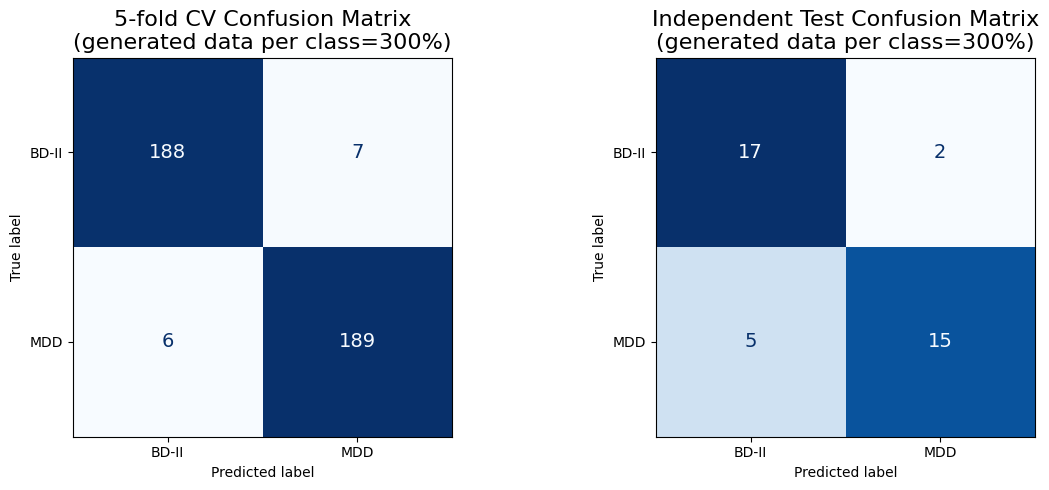

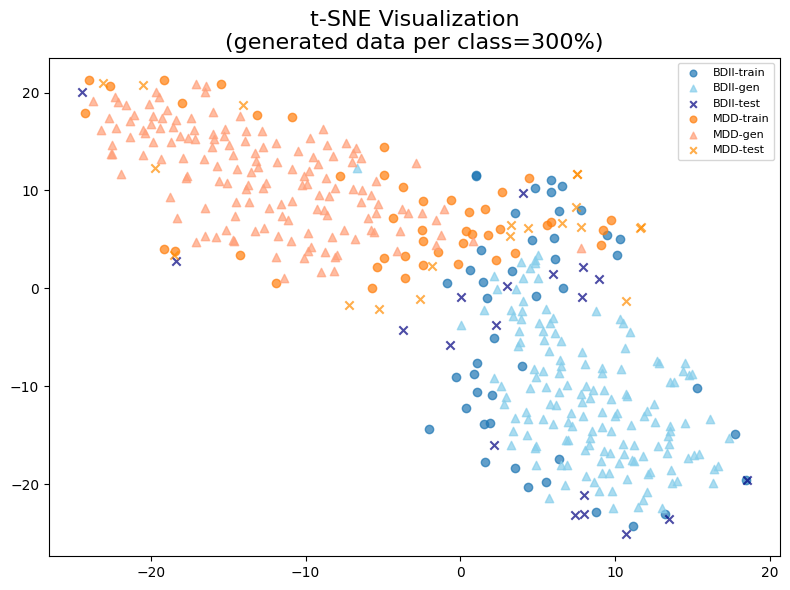

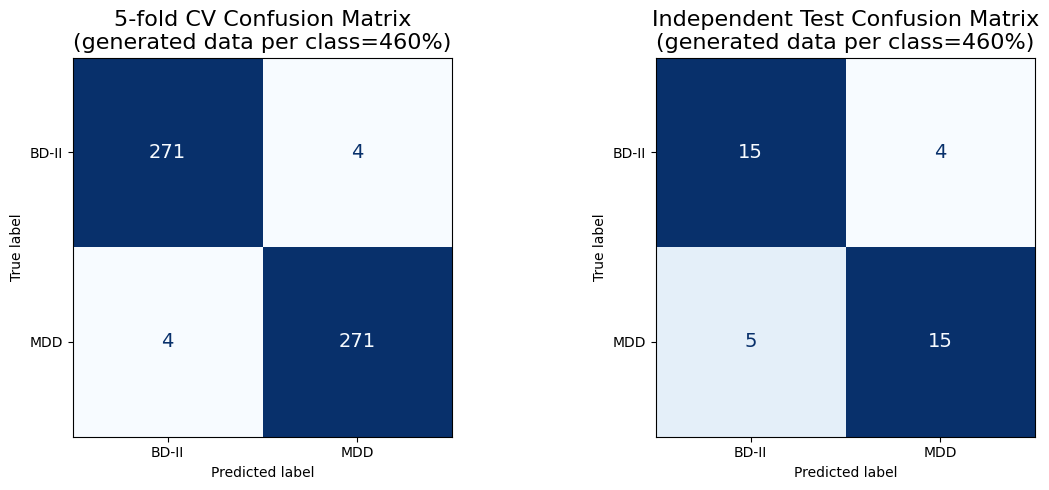

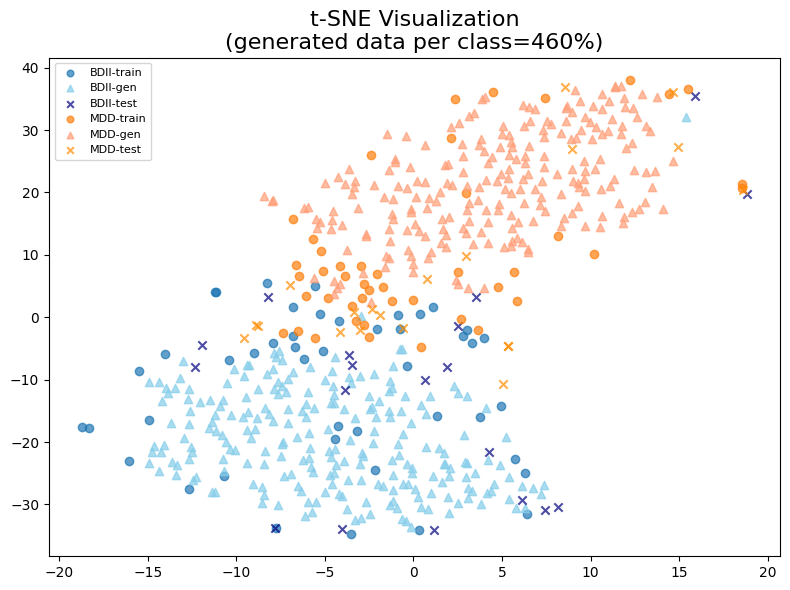

In [22]:
plot_combined_confusion_cnn(best_r_test, all_generated[best_r_test])
plot_tsne_cnn(best_r_test, all_generated[best_r_test])


plot_combined_confusion_cnn(best_r_cv, all_generated[best_r_cv])
plot_tsne_cnn(best_r_cv, all_generated[best_r_cv])

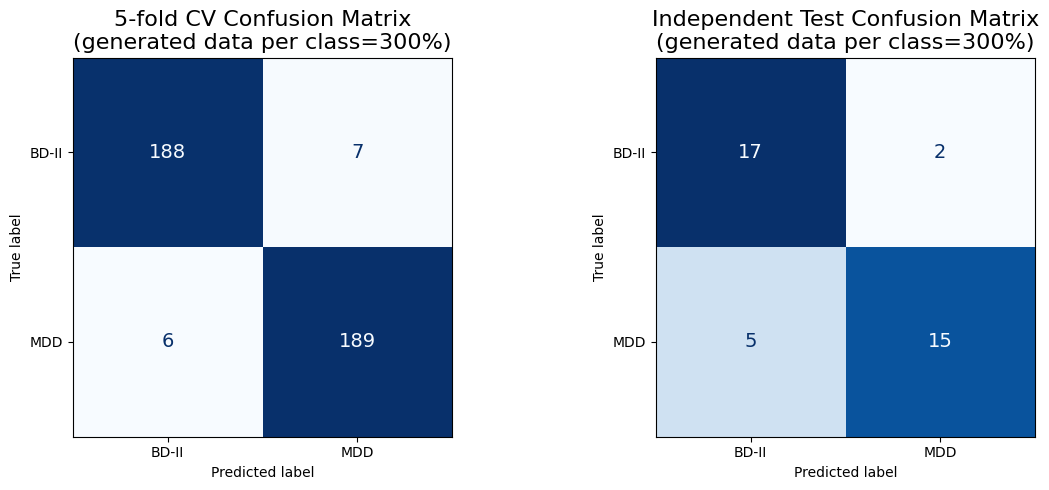

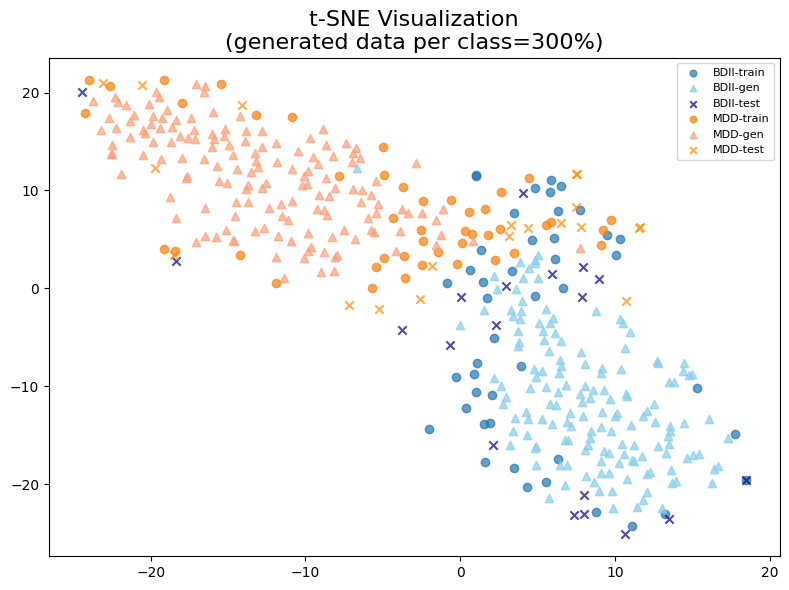

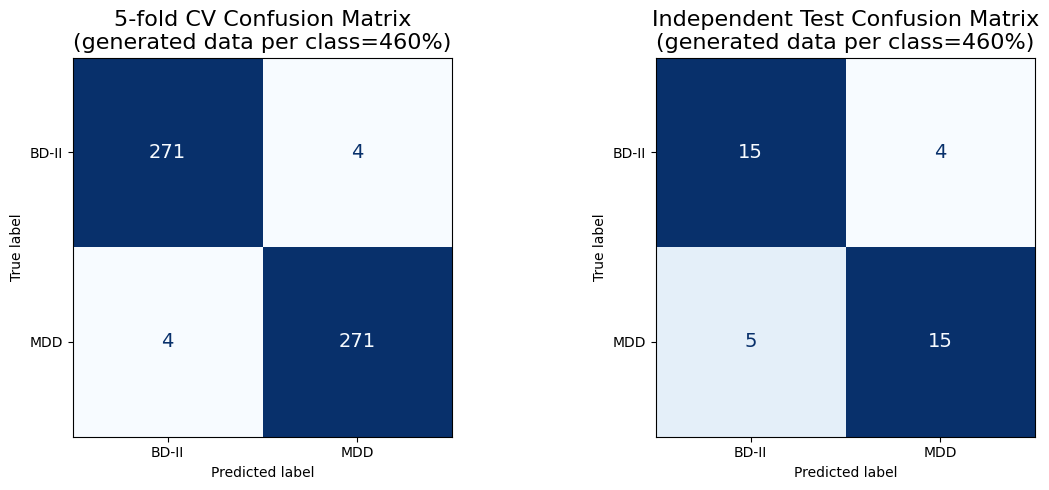

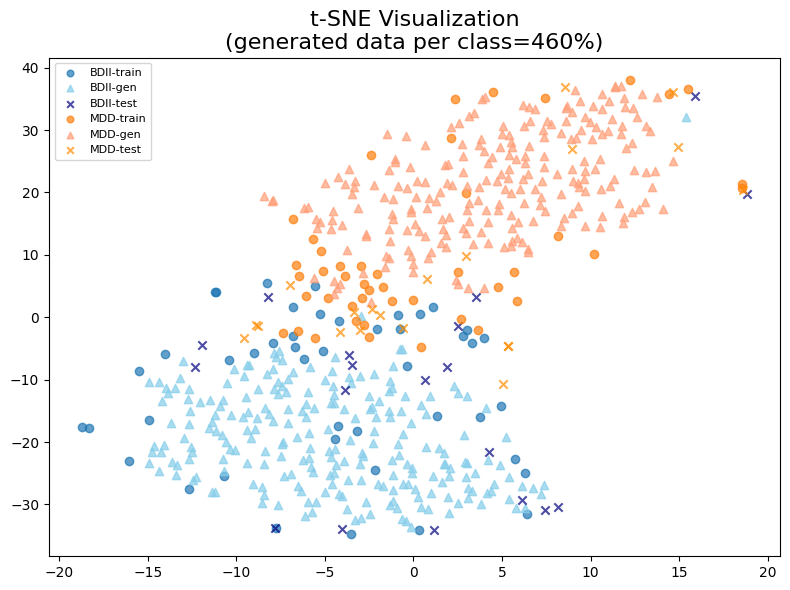

In [23]:
plot_combined_confusion_cnn(best_r_test, all_generated[best_r_test], '../result_DL/BD_MDD/w_DA/bvae/confusion_matrix_cnn_test.png')
plot_tsne_cnn(best_r_test, all_generated[best_r_test], '../result_DL/BD_MDD/w_DA/bvae/tsne_cnn_test.png')


plot_combined_confusion_cnn(best_r_cv, all_generated[best_r_cv], '../result_DL/BD_MDD/w_DA/bvae/confusion_matrix_cnn_cv.png')
plot_tsne_cnn(best_r_cv, all_generated[best_r_cv], '../result_DL/BD_MDD/w_DA/bvae/tsne_cnn_cv.png')